## Working with GEOREF in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/13_georef.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/13_georef.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/13_georef.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://demo.gishub.vn/lab/index.html?path=notebooks/vgrid/13_georef.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2georef

In [1]:
from vgrid.conversion.latlon2dggs import latlon2georef

lat = 10.775276
lon = 106.706797
res = 4
georef_id = latlon2georef(lat, lon, res)
georef_id

'VGBL42404651'

### GEOREF to Polygon

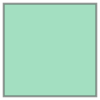

In [2]:
from vgrid.conversion.dggs2geo.georef2geo import georef2geo
from vgrid.dggs.georef import decode

georef_geo = georef2geo(georef_id)
georef_geo

### GEOREF to GeoJSON        

In [3]:
from vgrid.conversion.dggs2geo.georef2geo import georef2geojson

georef_geojson = georef2geojson(georef_id)
georef_geojson

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': (((106.70666666666666, 10.775166666666665),
      (106.70683333333334, 10.775166666666665),
      (106.70683333333334, 10.775333333333332),
      (106.70666666666666, 10.775333333333332),
      (106.70666666666666, 10.775166666666665)),)},
   'properties': {'georef': 'VGBL42404651',
    'resolution': 4,
    'center_lat': 10.77525,
    'center_lon': 106.70675,
    'cell_width': 18.228257216110396,
    'cell_height': 18.435516128085045,
    'cell_area': 336.04723747074604,
    'cell_perimeter': 73.32753666249707}}]}

### Vector to GEOREF

d:\Github\vgrid\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option COMPACT
  return ogr_read(
Processing features: 100%|██████████| 1/1 [00:00<00:00, 18.66it/s]


<Axes: >

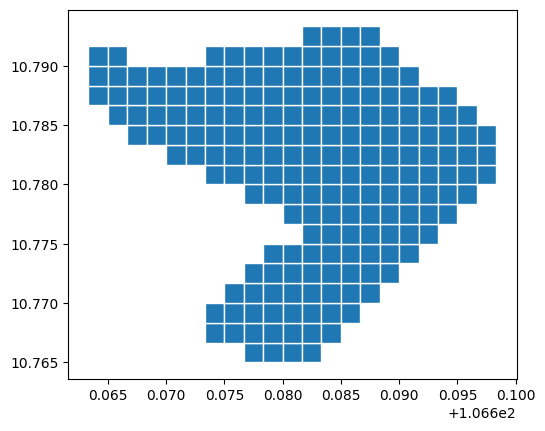

In [ ]:
from vgrid.conversion.vector2dggs.vector2georef import vector2georef

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
vector_to_georef = vector2georef(
    file_path,
    resolution=3,
    compact=False,
    topology=False,
    predicate="intersects",
    output_format="gpd",
)
# Visualize the output
# vector_to_georef
vector_to_georef.plot(edgecolor="white")

### GEOREF Binning

Generating GEOREF DGGS: 100%|██████████| 110/110 [00:00<00:00, 7906.73 cells/s]


<Axes: >

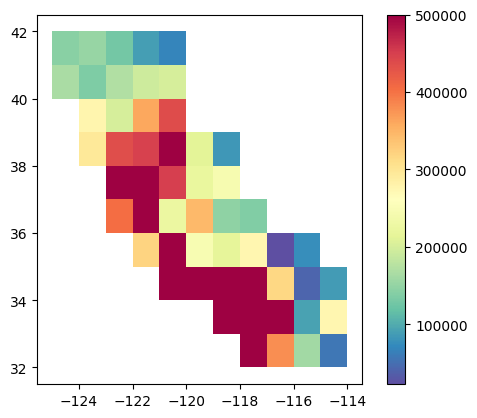

In [4]:
from vgrid.binning.georefbin import georefbin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
stats = "max"
numeric_col="median_house_value"

georef_bin = georefbin(
    file_path,
    resolution=1,
    stats=stats,
    numeric_col=numeric_col,
    # category_col="category",
    output_format="gpd",
)
georef_bin.plot(
    column= f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to GEOREF

#### Download and open raster

rgb.tif already exists. Skip downloading. Set overwrite=True to overwrite.
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 240, 'height': 147, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]'), 'transform': Affine(2.6640125000199077e-06, 0.0, 106.708118755,
       0.0, -2.6640136054383103e-06, 10.812568272)}


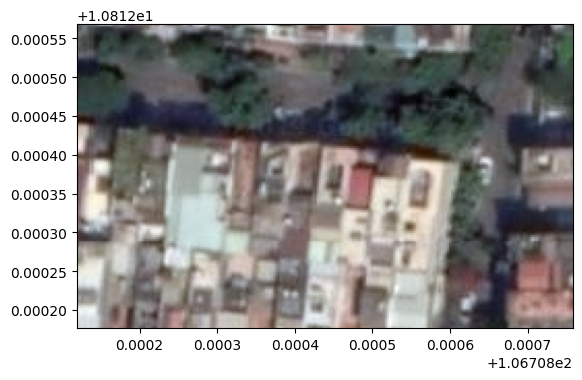

<Axes: >

In [3]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to GEOREF


In [ ]:
# %pip install folium

In [6]:
from vgrid.conversion.raster2dggs.raster2georef import raster2georef

raster_to_georef = raster2georef(raster_file, 
                                method = 'binning', # nearest, binning
                                stats = 'mean', output_format="gpd")

# Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

georef_layer = folium.GeoJson(
    raster_to_georef,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 1,
    },
    popup=folium.GeoJsonPopup(
        fields=["georef", "band_1", "band_2", "band_3"],
        aliases=["GEOREF ID", "Band 1", "Band 2", "Band 3"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(georef_layer.get_bounds())

# Display the map
m

Cell size: 0.08638527081938627 m2
Nearest GEOREF resolution determined: 5
Method: binning
Stats: mean


Converting raster to GEOREF: 100%|██████████| 975/975 [00:00<00:00, 31304.13 cells/s]


### GEOREF Generator

Generating GEOREF DGGS: 100%|██████████| 288/288 [00:00<00:00, 6626.69 cells/s]


<Axes: >

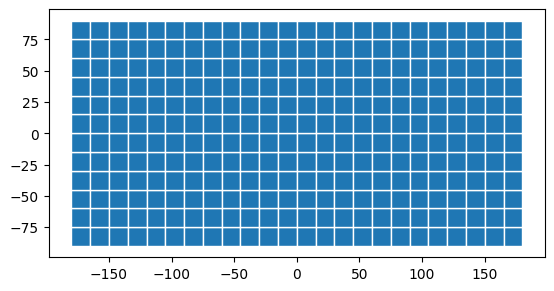

In [14]:
from vgrid.generator.georefgrid import georefgrid
georef_grid = georefgrid(resolution=0)
# georef_grid = georefgrid(resolution=1,bbox=[104.03833902,8.53410125,111.92366325,12.80076792])
georef_grid.plot(edgecolor="white")

### GEOREF Inspect

In [6]:
from vgrid.stats.georefstats import georefinspect

resolution = 1
georef_inspect = georefinspect(resolution)
georef_inspect.head()

Generating GEOREF DGGS: 100%|██████████| 64800/64800 [00:06<00:00, 10309.45 cells/s]


,georef,resolution,center_lat,center_lon,cell_width,cell_height,cell_area,cell_perimeter,geometry,crossed,norm_area,ipq,zsc,cvh
0,AAAA,1,-89.5,-179.5,0.000000,111693.864914,1.088612e+08,225337.031822,"POLYGON ((-180 -90, -179 -90, -179 -89, -180 -...",False,0.013830,0.026941,0.164138,1.0
1,AAAB,1,-88.5,-179.5,1949.301993,111693.177216,3.265476e+08,229233.654684,"POLYGON ((-180 -89, -179 -89, -179 -88, -180 -...",False,0.041485,0.078091,0.279447,1.0
2,AAAC,1,-87.5,-179.5,3897.998258,111691.802680,5.441267e+08,233127.086900,"POLYGON ((-180 -88, -179 -88, -179 -87, -180 -...",False,0.069127,0.125813,0.354701,1.0
3,AAAD,1,-86.5,-179.5,5845.483282,111689.743022,7.615267e+08,237016.121318,"POLYGON ((-180 -87, -179 -87, -179 -86, -180 -...",False,0.096746,0.170349,0.412733,1.0
4,AAAE,1,-85.5,-179.5,7791.151992,111687.000814,9.786761e+08,240899.553582,"POLYGON ((-180 -86, -179 -86, -179 -85, -180 -...",False,0.124333,0.211922,0.460350,1.0


### GEOREF Normalized Area Histogram

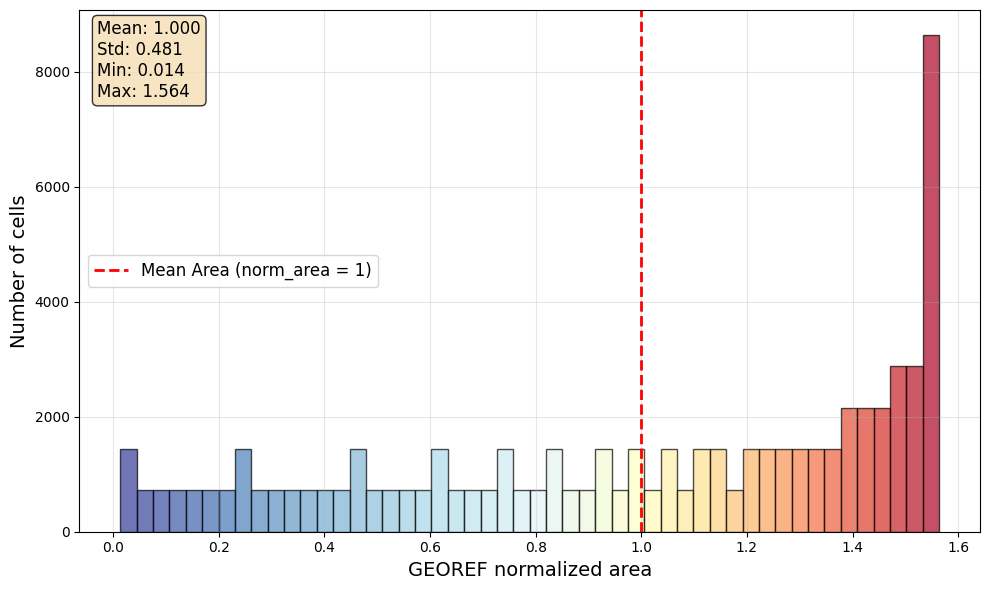

In [7]:
from vgrid.stats.georefstats import georef_norm_area_hist

georef_norm_area_hist(georef_inspect)

### Distribution of GEOREF Area Distortions

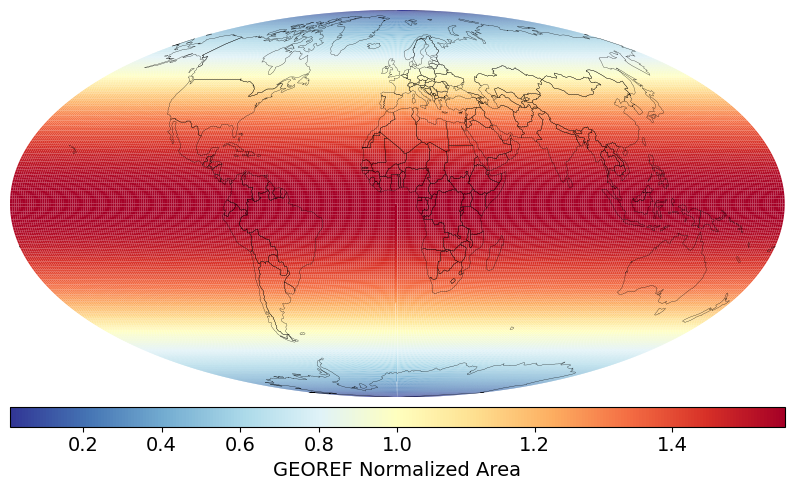

In [8]:
from vgrid.stats.georefstats import georef_norm_area

georef_norm_area(georef_inspect)

### GEOREF IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is [0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.

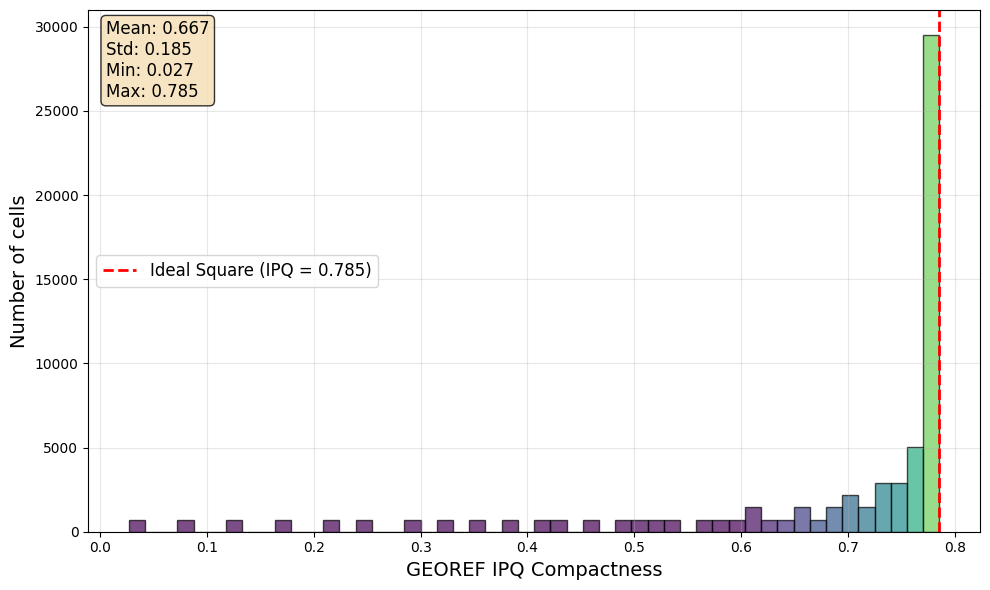

In [9]:
from vgrid.stats.georefstats import georef_compactness_ipq_hist

georef_compactness_ipq_hist(georef_inspect)

### Distribution of GEOREF IPQ Compactness

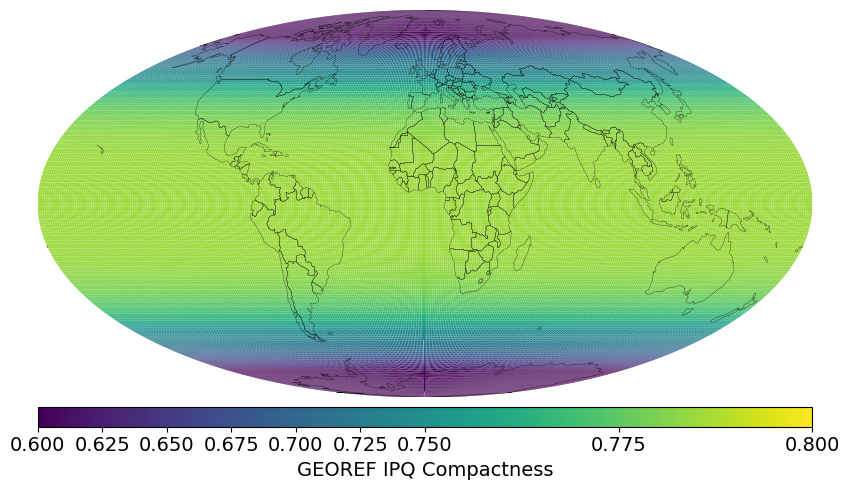

In [10]:
from vgrid.stats.georefstats import georef_compactness_ipq

georef_compactness_ipq(georef_inspect)

### GEOREF Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is [0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

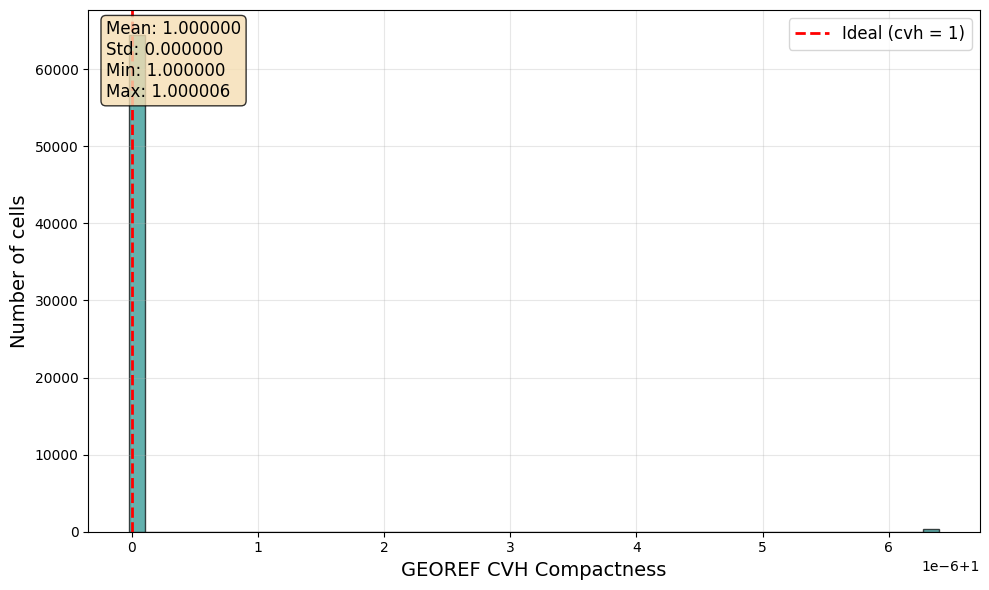

In [11]:
from vgrid.stats.georefstats import georef_compactness_cvh_hist
georef_compactness_cvh_hist(georef_inspect)

### Distribution of GEOREF Convex hull Compactness

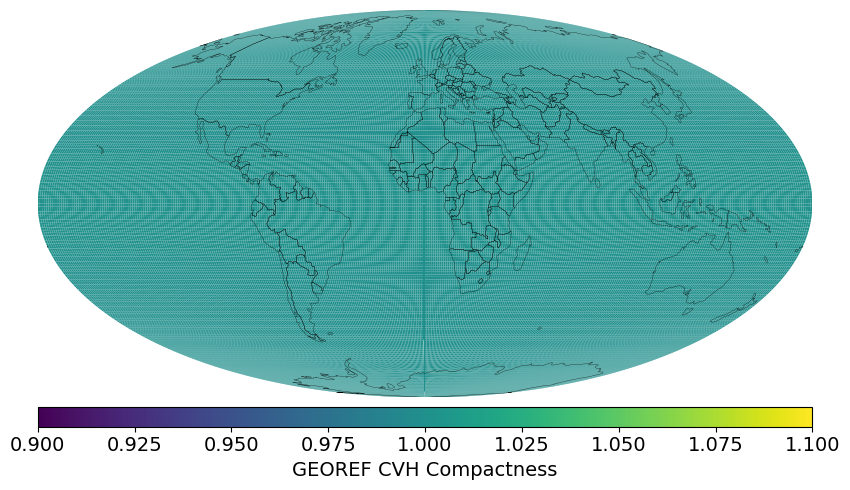

In [12]:
from vgrid.stats.georefstats import georef_compactness_cvh
georef_compactness_cvh(georef_inspect)

### GEOREF Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [13]:
from vgrid.stats import georefstats

georefstats("m")

,resolution,number_of_cells,avg_edge_len_m,avg_cell_area_m2,cls_m
0,0,288,1.330812e+06,1.771061e+12,1.502531e+06
1,1,64800,8.872082e+04,7.871383e+09,1.001110e+05
2,2,233280000,1.478680e+03,2.186495e+06,1.668512e+03
3,3,23328000000,1.478680e+02,2.186495e+04,1.668512e+02
4,4,2332800000000,1.478680e+01,2.186495e+02,1.668512e+01
5,5,233280000000000,1.478680e+00,2.186495e+00,1.668512e+00
6,6,23328000000000000,1.478680e-01,2.186495e-02,1.668512e-01
7,7,233280000000000000000,1.478680e-03,2.186495e-06,1.668512e-03
8,8,23328000000000000000000,1.478680e-04,2.186495e-08,1.668512e-04
9,9,233280000000000000000000000,1.478680e-06,2.186495e-12,1.668512e-06
